Climate Grooves: Sonification of climate data


Input parameters and data files

In [2]:
import numpy as np
from sonification import sonification

sequence = 32       # Length of the sequence (16, 32, 64, ...)
lowest = 6           # Note in scale on which to start the sequence (1-7)
key = 'Eb'            # 12 keys to choose from (no sharps, only flats)
span = 14            # Tonal span of the sequence (14 = 2 octaves for Major; 2.5 for blues & pentatonic)
IPmethod = 1
scale = 'Blues'
abc = 1              # Write output on pdf file using abc software
outputname = 'ShelfMelt'

import pandas as pd
T = pd.read_csv('EIS8_2021_bmb.txt', delim_whitespace=True)

data = np.zeros((len(T), 2))
data[:, 0] = np.linspace(0, 1, len(data))
data[:, 1] = T.iloc[:, 1].values

#data = np.loadtxt('ImbieAntarctica.txt')
#data[:, 1] = -data[:, 1]



Run the sonification algorithm

In [3]:
# Interpolation to length of the sequence
time = np.linspace(data[0, 0], data[-1, 0], sequence)
var = np.interp(time, data[:, 0], data[:, 1])

# retrieval of scale and melody information
ScaleIndices, NewScale = sonification(
    var, lowest, key, span, outputname, IPmethod, scale, abc
)

Plot the results

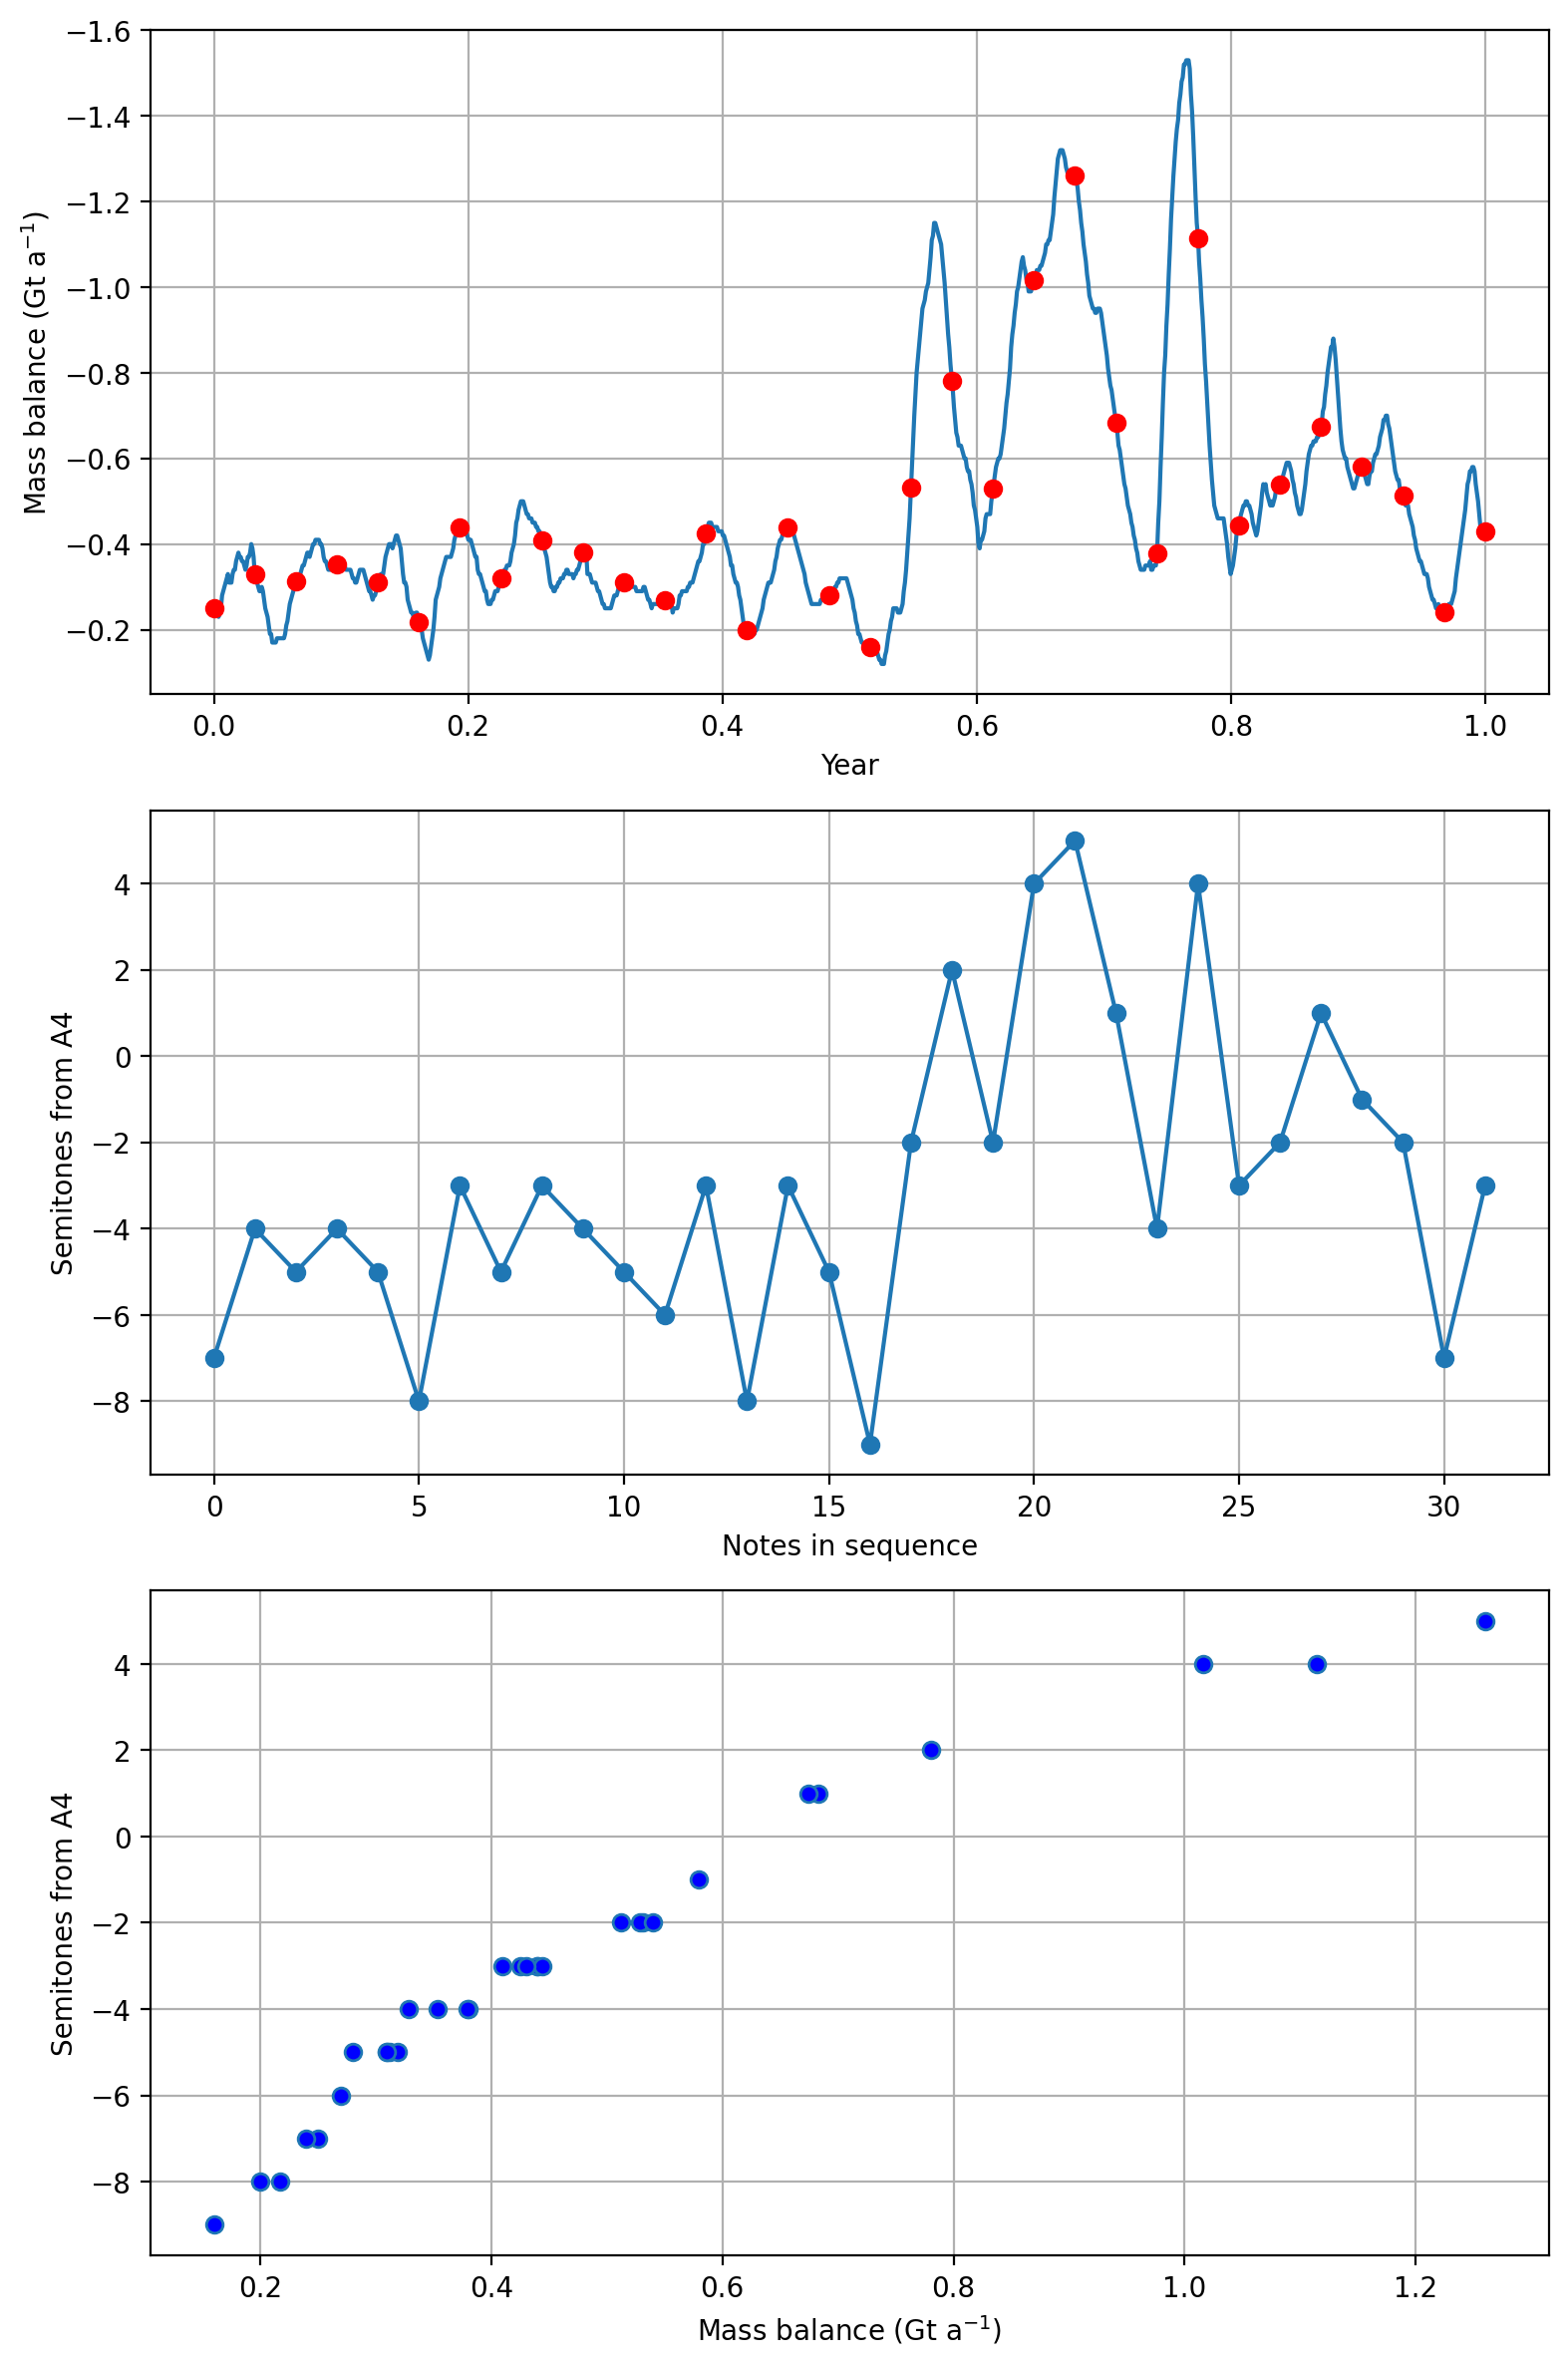

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# Subplot 1: mass balance time series with sampled points overlaid
axes[0].plot(data[:, 0], -data[:, 1], '-', linewidth=1.5)
axes[0].plot(time, -var, 'ro', linewidth=1.5)
axes[0].invert_yaxis()
#axes[0].set_ylim(50, -250)  # reversed axis: upper limit first
axes[0].set_xlabel('Year')
axes[0].set_ylabel(r'Mass balance (Gt a$^{-1}$)')
axes[0].grid(True)

# Subplot 2: scale indices as semitones from A4
axes[1].plot(ScaleIndices - 9, 'o-', linewidth=1.5)
axes[1].grid(True)
# axes[1].set_xlim(0, 18)
axes[1].set_xlabel('Notes in sequence')
axes[1].set_ylabel('Semitones from A4')

# Subplot 3: mass balance vs semitones
axes[2].plot(var, ScaleIndices - 9, 'o', markerfacecolor='b')
axes[2].grid(True)
axes[2].set_xlabel(r'Mass balance (Gt a$^{-1}$)')
axes[2].set_ylabel('Semitones from A4')

plt.tight_layout()
plt.show()

Display ABC code

In [5]:
with open(f'{outputname}.abc') as f:
    for line in f:
        print(line, end='')

X: 1
T: ShelfMelt
M: 4/4
L: 1/4
K: Eb
F,_B,G,_B,|G,_E,CG,|C_B,G,^F,|C_E,CG,|
C,_E_B_E|_efG_B,|_eC_EG|F_EF,C|


In [6]:
from IPython.display import IFrame, display

if abc == 1:
    display(IFrame(f'{outputname}.pdf', width=800, height=600))

In [8]:
#!pip install music21
from music21 import converter

score = converter.parse(f'{outputname}.abc')
score.show('midi')